# Test PTA-simulator

We simulate a small PTA with i.i.d. zero mean Gaussian white noise, intrinsic pulsar noise, and a stochastic GWB with PTA-simulator. We then perform parameter estimation with Prometheus.

In [ ]:
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import numpy as np
import matplotlib.pyplot as plt
import corner

from pulsar import Pulsar, simulate_toas
from pta import PTA
from data import SimulatedData

from prometheus.spectral_models import CommonSpectralModel, IndependentSpectralModel
from prometheus import spectra
from prometheus.pta_model import PTAModel
from prometheus.utilities import renorm
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
import jax.random as jr

## Simulate data

In [2]:
# create simulated pulsars
npsrs = 20
psrs = []
for i in range(npsrs):
    toas = simulate_toas(53_000, 15., seed=i)
    psr = Pulsar(name=f'PSR{i}',
                 costheta=np.random.uniform(-1, 1),
                 phi=np.random.uniform(0, 2 * np.pi),
                 dist_kpc=np.random.uniform(0.5, 5.),
                 dist_kpc_std=0.2,
                 toas=toas,
                 toa_errors=np.ones_like(toas) * 0.5e-6)
    psrs.append(psr)

In [3]:
# create PTA
pta = PTA(psrs)

# add white noise
pta.add_white_noise(seed=150914)

# add intrinsic pulsar noise and a GWB
log10_A_gwb = -14.
gamma_gwb = 13 / 3
log10_As_rn = np.random.uniform(-17.5, -13., size=npsrs)
gammas_rn = np.random.uniform(2, 5, size=npsrs)
pta.add_irn_gwb_delay(log10_As_rn, gammas_rn, log10_A_gwb, gamma_gwb, seed=170817)

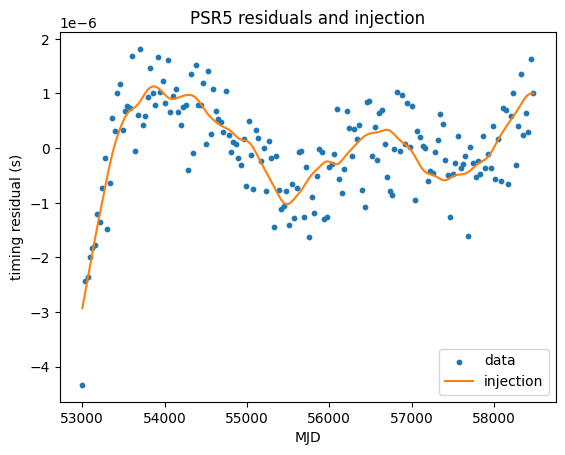

In [6]:
# show data / injection for one pulsar
psr_ndx = 5
plt.scatter(psrs[psr_ndx].mjds, psrs[psr_ndx].projected_residuals(), s=10, label='data')
plt.plot(psrs[psr_ndx].mjds, psrs[psr_ndx].R @ pta.Fs[psr_ndx] @ pta.params_inj['a'][psr_ndx], color='C1', label='injection')
plt.xlabel('MJD')
plt.ylabel('timing residual (s)')
plt.legend()
plt.title(f'{psrs[psr_ndx].name} residuals and injection')
plt.show()

In [7]:
# create prometheus compatible data object
data = SimulatedData(pta, name='simulated_data')

building pulsar models: 100%|██████████| 20/20 [00:02<00:00,  9.72it/s, running PSR19]


## Parameter estimation

In [8]:
# spectral models
psr_model = IndependentSpectralModel(name='psr_params',
                                     parameter_bounds=[[-20., -10.],
                                                       [0., 7.]],
                                     data=data,
                                     get_phi_diag_func=spectra.power_law)
gwb_model = CommonSpectralModel(name='gwb_params',
                                parameter_bounds=[[-20., -10.],
                                                [0., 7.]],
                                data=data,
                                get_phi_diag_func=spectra.power_law,
                                correlation_matrix='HD')
pta_model = PTAModel(psr_model=psr_model,
                     gwb_model=gwb_model)

In [9]:
# test posterior evaluation
psr_params = jnp.array([[-15., 4.]] * npsrs)
gwb_params = jnp.array([-14.5, 13 / 3])
z = jnp.zeros((pta_model.npsrs, pta_model.ncomponents))
print(pta_model.ln_posterior(z, psr_params, gwb_params))

26123.03


In [10]:
%timeit pta_model.ln_posterior(z, psr_params, gwb_params)

224 μs ± 249 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [11]:
# HMC sampling
nuts_kernel = numpyro.infer.NUTS(pta_model.sampling_model)
mcmc = numpyro.infer.MCMC(nuts_kernel,
                          num_warmup=1000,
                          num_samples=5000)
mcmc.run(jr.key(200129))
samples = mcmc.get_samples()

sample: 100%|██████████| 6000/6000 [08:50<00:00, 11.31it/s, 127 steps of size 3.81e-02. acc. prob=0.94]


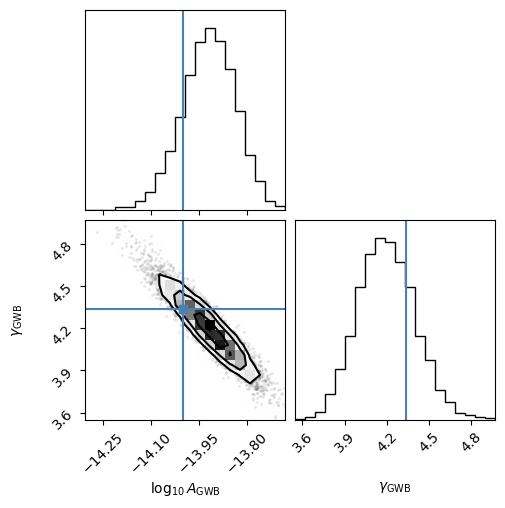

In [12]:
# plot GWB posterior
gwb_samples = np.array(samples['gwb_params'])
fig = corner.corner(data=gwb_samples,
                    labels=[r'$\log_{10}A_\text{GWB}$', r'$\gamma_\text{GWB}$'],
                    truths=[log10_A_gwb, gamma_gwb])

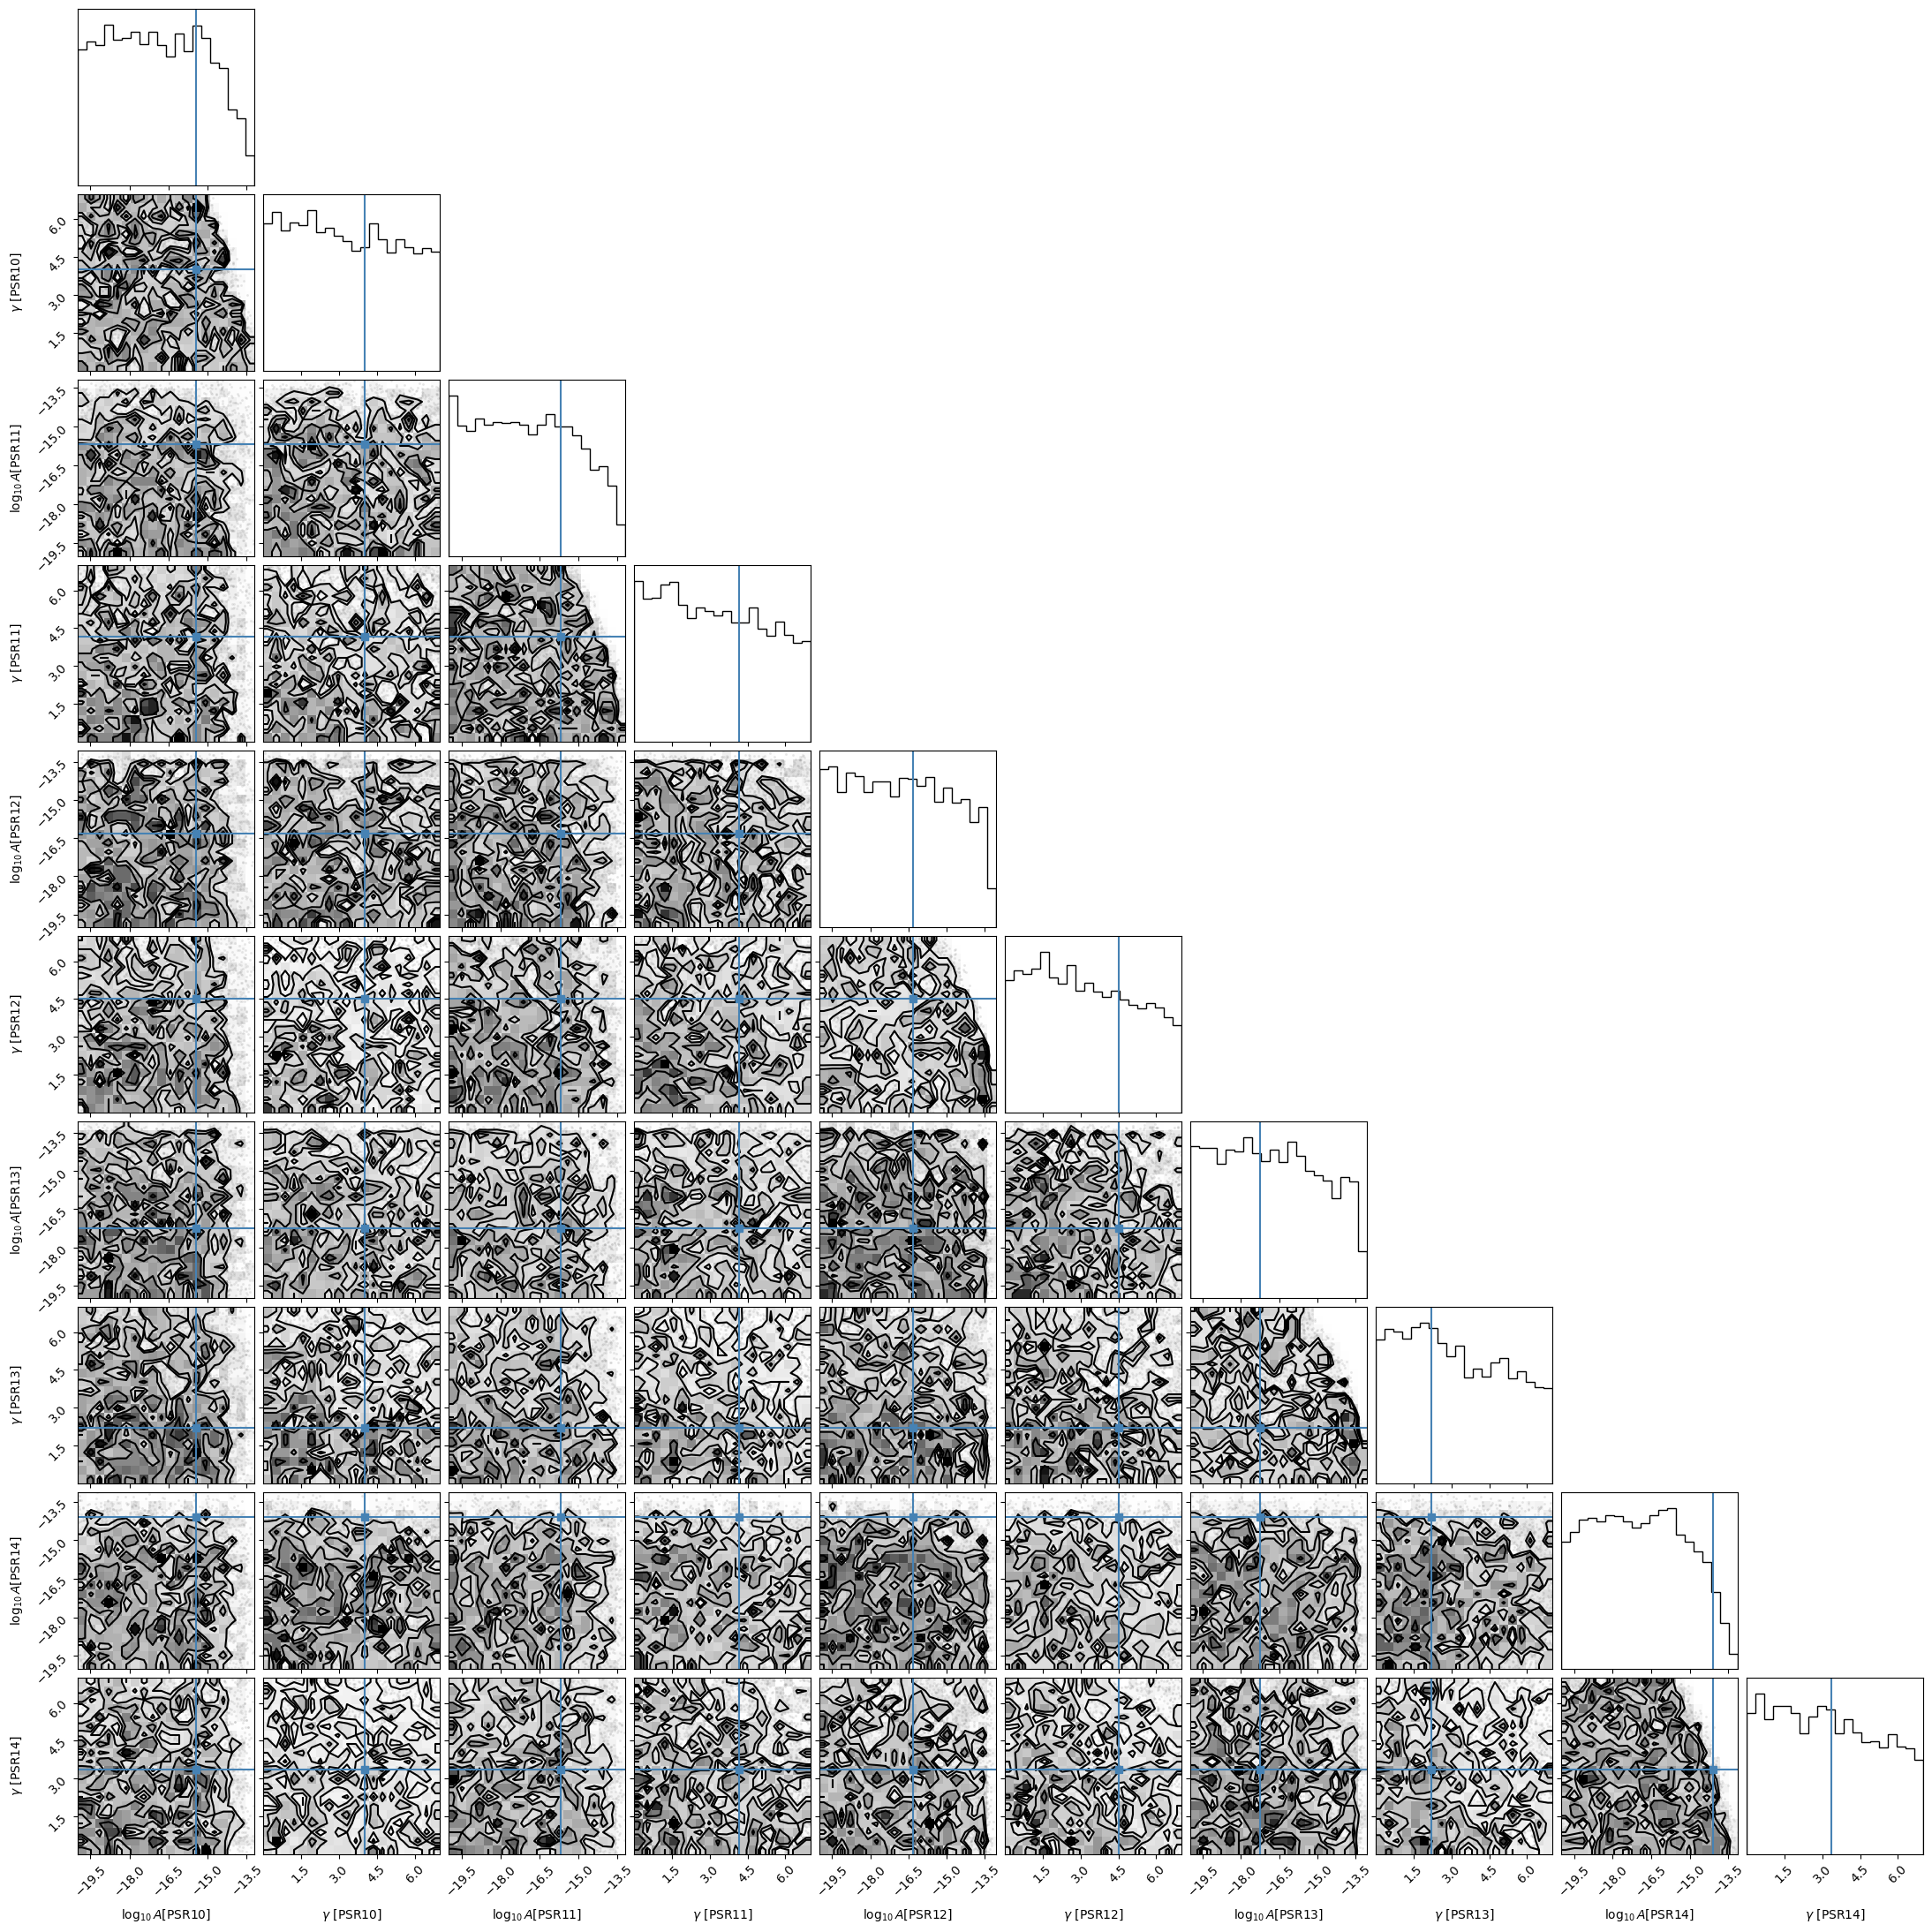

In [28]:
# plot RN posterior
psr_ndxs = np.r_[10:15]
rn_samples = np.array(samples['psr_params'])[:, psr_ndxs].reshape((-1, 2 * len(psr_ndxs)))
rn_labels = np.array([[r'$\log_{10}A$' + f'[{psrs[ndx].name}]', rf'$\gamma$ [{psrs[ndx].name}]']
                      for ndx in psr_ndxs]).flatten()
rn_truths = np.array([[log10_As_rn[ndx], gammas_rn[ndx]] for ndx in psr_ndxs]).flatten()
fig = corner.corner(data=rn_samples,
                    labels=rn_labels,
                    truths=rn_truths)

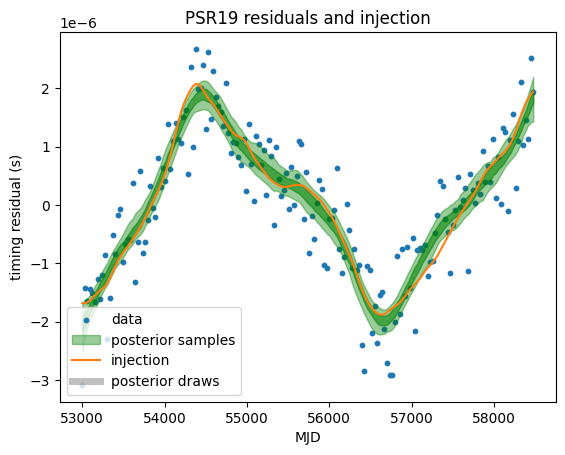

In [29]:
# time-domain recovery
psr_ndx = 19
psr = psrs[psr_ndx]
plt.scatter(psr.mjds, psr.projected_residuals(), s=10, label='data', color='C0')
fair_draws_ndxs = np.random.choice(len(samples['psr_params']), size=100, replace=False)
fair_draw_signals = np.array([psr.R @ pta.Fs[psr_ndx] @ samples['a'][i, psr_ndx] / renorm
                              for i in fair_draws_ndxs])
plt.fill_between(psr.mjds,
                 np.percentile(fair_draw_signals, 2.5, axis=0),
                 np.percentile(fair_draw_signals, 97.5, axis=0),
                 color='green', alpha=0.4, label='posterior samples')
plt.fill_between(psr.mjds,
                 np.percentile(fair_draw_signals, 25, axis=0),
                 np.percentile(fair_draw_signals, 75, axis=0),
                 color='green', alpha=0.55)
plt.plot(psr.mjds, psr.R @ pta.Fs[psr_ndx] @ pta.params_inj['a'][psr_ndx], color='C1', label='injection')
plt.plot([], [], color='grey', alpha=0.5, label='posterior draws', lw=5)
plt.xlabel('MJD')
plt.ylabel('timing residual (s)')
plt.legend()
plt.title(f'{psr.name} residuals and injection')
plt.show()